# Bangalore LULC Change Prediction: Improved CA-ANN
## Based on Amoah & Gorsevski (2025) — Ghana methodology adapted for Bengaluru
**Time periods:** 2005 → 2015 → 2025 → predict 2035 & 2045  
**Key improvements over baseline:**
- Stacked ensemble: Random Forest (spatial) + MLP (ANN) for transition potential
- Larger, spatially-stratified training samples (up to 15k/class)
- Multi-scale neighborhood features (3×3, 5×5, 11×11 windows)
- Improved CA allocation: class-constraint + persistence bonus + stochastic perturbation
- Two-phase training: calibrate on 2005→2015, fine-tune on 2015→2025
- Pearson correlation-based driver selection (drops collinear drivers)
- Quantity & Allocation disagreement validation (Pontius & Millones 2011)


In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "rasterio", "numpy", "pandas", "matplotlib",
                       "seaborn", "scikit-learn", "scipy", "--quiet"])

0

## 0. Install / Import Libraries

In [2]:
# ── Run this cell once, then restart kernel if needed ──
# pip install numpy pandas matplotlib seaborn scikit-learn rasterio scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, time
from pathlib import Path
from scipy.ndimage import uniform_filter, label as nd_label, generic_filter
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.inspection import permutation_importance
import rasterio
from rasterio.transform import from_bounds

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

DATA_DIR = Path('.')   # ← adjust if TIFs are elsewhere

print('✓ Libraries loaded.')


✓ Libraries loaded.


## 1. Load Data

In [3]:
def load_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        meta = src.meta.copy()
        nodata = src.nodata
    return data, meta, nodata

def load_raster_masked(path):
    data, meta, nodata = load_raster(path)
    if nodata is not None:
        data[data == nodata] = np.nan
    return data, meta

# ── Load classified LULC maps ──
lulc_2005, meta_2005, _ = load_raster(DATA_DIR / 'classified2005.tif')
lulc_2015, meta_2015, _ = load_raster(DATA_DIR / 'classified_2015.tif')
lulc_2025, meta_2025, _ = load_raster(DATA_DIR / 'classified2025.tif')

print('Raw LULC shapes:', lulc_2005.shape, lulc_2015.shape, lulc_2025.shape)

# ── Align to minimum common shape ──
min_rows = min(lulc_2005.shape[0], lulc_2015.shape[0], lulc_2025.shape[0])
min_cols = min(lulc_2005.shape[1], lulc_2015.shape[1], lulc_2025.shape[1])
lulc_2005 = lulc_2005[:min_rows, :min_cols]
lulc_2015 = lulc_2015[:min_rows, :min_cols]
lulc_2025 = lulc_2025[:min_rows, :min_cols]

meta = meta_2015.copy()
meta.update({'height': min_rows, 'width': min_cols})

# ── Strip 255 nodata sentinel from 2005 ──
LULC_NODATA = 255
lulc_2005[lulc_2005 == LULC_NODATA] = np.nan

print('Aligned LULC shapes:', lulc_2005.shape, lulc_2015.shape, lulc_2025.shape)
print('CRS:', meta['crs'])
print('Resolution:', abs(meta['transform'].a), 'm/pixel')

for yr, arr in [('2005', lulc_2005), ('2015', lulc_2015), ('2025', lulc_2025)]:
    vals = np.unique(arr[~np.isnan(arr)]).astype(int)
    print(f'  {yr} classes: {vals}')


Raw LULC shapes: (2069, 2269) (2068, 2268) (2068, 2268)
Aligned LULC shapes: (2068, 2268) (2068, 2268) (2068, 2268)
CRS: EPSG:32643
Resolution: 30.0 m/pixel
  2005 classes: [1 2 3 4]
  2015 classes: [1 2 3 4]
  2025 classes: [1 2 3 4]


In [4]:
# ── Class label map — adjust to your classification scheme ──
CLASS_MAP = {
    1: 'Built-up',
    2: 'Vegetation',
    3: 'Water',
    4: 'Bare Land',
}

NODATA_SENTINELS = {0, 255}

all_vals = set()
for arr in [lulc_2005, lulc_2015, lulc_2025]:
    all_vals.update(np.unique(arr[~np.isnan(arr)]).astype(int).tolist())

missing = all_vals - set(CLASS_MAP.keys()) - NODATA_SENTINELS
if missing:
    print(f'INFO: Auto-labelling class IDs: {sorted(missing)}')
    for c in sorted(missing):
        CLASS_MAP[c] = f'Class_{c}'
for bad in NODATA_SENTINELS:
    CLASS_MAP.pop(bad, None)

print('Class mapping:', CLASS_MAP)
N_CLASSES = len(CLASS_MAP)
CLASS_IDS  = sorted(CLASS_MAP.keys())


Class mapping: {1: 'Built-up', 2: 'Vegetation', 3: 'Water', 4: 'Bare Land'}


In [5]:
# ── Load driver variables ──
DRIVER_FILES = {
    'Elevation':           DATA_DIR / 'Elevation.tif',
    'Slope':               DATA_DIR / 'Slope.tif',
    'Dist_PrimaryRoad':    DATA_DIR / 'EucDist_PrimaryRoad.tif',
    'Dist_SecondaryRoad':  DATA_DIR / 'EucDist_secondaryRoads.tif',
    'Dist_RoadNetwork':    DATA_DIR / 'EucDist_roadnetwork.tif',
    'Dist_Waterbody':      DATA_DIR / 'EucDist_waterbody.tif',
    'Dist_RailwayStation': DATA_DIR / 'EucDist_railwaySt.tif',
    'Dist_Metro':          DATA_DIR / 'Distance_metro.tif',
}

drivers = {}
for name, fpath in DRIVER_FILES.items():
    arr, _ = load_raster_masked(fpath)
    arr = arr[:min_rows, :min_cols]   # ensure alignment
    drivers[name] = arr
    print(f'  {name}: min={np.nanmin(arr):.2f}, max={np.nanmax(arr):.2f}')

print(f'\nLoaded {len(drivers)} driver variables.')


  Elevation: min=649.00, max=1031.00
  Slope: min=0.00, max=71.17
  Dist_PrimaryRoad: min=0.00, max=11400.16
  Dist_SecondaryRoad: min=0.00, max=6831.84
  Dist_RoadNetwork: min=0.00, max=1758.01
  Dist_Waterbody: min=0.00, max=29209.37
  Dist_RailwayStation: min=0.00, max=25690.16
  Dist_Metro: min=0.00, max=32599.63

Loaded 8 driver variables.


## 2. Preprocessing & Feature Engineering

In [6]:
rows, cols = lulc_2005.shape
PIXEL_AREA_HA = (abs(meta['transform'].a) * abs(meta['transform'].e)) / 10000

def normalize_driver(arr):
    mn, mx = np.nanmin(arr), np.nanmax(arr)
    if mx == mn:
        return np.zeros_like(arr)
    out = (arr - mn) / (mx - mn)
    out[np.isnan(arr)] = np.nan
    return out.astype(np.float32)

drivers_norm = {k: normalize_driver(v) for k, v in drivers.items()}

# ── Valid mask: every layer must be non-NaN ──
valid_mask = np.ones((rows, cols), dtype=bool)
for arr in drivers_norm.values():
    valid_mask &= ~np.isnan(arr)
valid_mask &= ~np.isnan(lulc_2005)
valid_mask &= ~np.isnan(lulc_2015)
valid_mask &= ~np.isnan(lulc_2025)

print(f'Valid pixels: {valid_mask.sum():,} / {rows*cols:,}  ({valid_mask.mean()*100:.1f}%)')

def safe_int(arr, mask):
    out = arr.copy()
    out[~mask] = 0
    return out.astype(np.int16)

L05 = safe_int(lulc_2005, valid_mask)
L15 = safe_int(lulc_2015, valid_mask)
L25 = safe_int(lulc_2025, valid_mask)


Valid pixels: 4,690,224 / 4,690,224  (100.0%)


In [7]:
# ── IMPROVEMENT 1: Multi-scale neighborhood features ──
# Original code only used 3×3. We add 5×5 and 11×11 for better
# spatial context — capturing local and regional urban patterns.

def compute_neighborhood_features(lulc_arr, class_ids, scales=(3, 5, 11)):
    """
    For each class and each spatial scale, compute the proportion
    of that class within the window. Returns list of 2D arrays.
    """
    feats = []
    for scale in scales:
        for cid in class_ids:
            binary = (lulc_arr == cid).astype(np.float32)
            prop   = uniform_filter(binary, size=scale, mode='reflect')
            feats.append(prop)
    return feats  # len = len(scales) * len(class_ids)

neigh_names_05 = [f'Neigh{s}_{CLASS_MAP[c]}' for s in (3,5,11) for c in CLASS_IDS]
print(f'Neighborhood feature count: {len(neigh_names_05)}')

# ── IMPROVEMENT 2: Driver collinearity check — drop highly correlated drivers ──
# Keeps the model focused on truly independent spatial signals.
rng = np.random.default_rng(42)
idx_valid = np.where(valid_mask.ravel())[0]
if len(idx_valid) > 80_000:
    idx_sample = rng.choice(idx_valid, 80_000, replace=False)
else:
    idx_sample = idx_valid

driver_matrix = np.column_stack([v.ravel()[idx_sample] for v in drivers_norm.values()])
corr_matrix   = np.corrcoef(driver_matrix, rowvar=False)
driver_names  = list(drivers_norm.keys())

CORR_THRESHOLD = 0.85
drop_set = set()
for i in range(len(driver_names)):
    for j in range(i+1, len(driver_names)):
        if abs(corr_matrix[i, j]) > CORR_THRESHOLD and driver_names[j] not in drop_set:
            drop_set.add(driver_names[j])
            print(f'  Dropping {driver_names[j]} (r={corr_matrix[i,j]:.2f} with {driver_names[i]})')

selected_drivers = {k: v for k, v in drivers_norm.items() if k not in drop_set}
print(f'\nSelected {len(selected_drivers)}/{len(drivers_norm)} drivers after collinearity filter:')
print('  ', list(selected_drivers.keys()))


Neighborhood feature count: 12

Selected 8/8 drivers after collinearity filter:
   ['Elevation', 'Slope', 'Dist_PrimaryRoad', 'Dist_SecondaryRoad', 'Dist_RoadNetwork', 'Dist_Waterbody', 'Dist_RailwayStation', 'Dist_Metro']


In [8]:
def build_features_v2(lulc_t1, selected_drivers, mask, scales=(3, 5, 11)):
    # Build feature matrix with selected drivers + multi-scale neighborhood features
    feats = [v.ravel() for v in selected_drivers.values()]
    neigh = compute_neighborhood_features(lulc_t1, CLASS_IDS, scales=scales)
    feats.extend([n.ravel() for n in neigh])
    X = np.column_stack(feats)
    valid_idx = np.where(mask.ravel())[0]
    return X, valid_idx

feature_names = (
    list(selected_drivers.keys()) +
    [f'Neigh{s}_{CLASS_MAP[c]}' for s in (3,5,11) for c in CLASS_IDS]
)
print(f'Total features: {len(feature_names)}')
print('Features:', feature_names)


Total features: 20
Features: ['Elevation', 'Slope', 'Dist_PrimaryRoad', 'Dist_SecondaryRoad', 'Dist_RoadNetwork', 'Dist_Waterbody', 'Dist_RailwayStation', 'Dist_Metro', 'Neigh3_Built-up', 'Neigh3_Vegetation', 'Neigh3_Water', 'Neigh3_Bare Land', 'Neigh5_Built-up', 'Neigh5_Vegetation', 'Neigh5_Water', 'Neigh5_Bare Land', 'Neigh11_Built-up', 'Neigh11_Vegetation', 'Neigh11_Water', 'Neigh11_Bare Land']


## 3. LULC Change Analysis

In [9]:
def area_stats(lulc, mask, class_map, pixel_ha):
    stats = {}
    total = mask.sum()
    for cid, cname in class_map.items():
        count = ((lulc == cid) & mask).sum()
        stats[cname] = {'pixels': count, 'ha': count * pixel_ha, 'pct': count / total * 100}
    return stats

def dynamic_degree(area_start, area_end, years):
    return (area_end - area_start) / (area_start * years) * 100 if area_start > 0 else 0

stats_05 = area_stats(L05, valid_mask, CLASS_MAP, PIXEL_AREA_HA)
stats_15 = area_stats(L15, valid_mask, CLASS_MAP, PIXEL_AREA_HA)
stats_25 = area_stats(L25, valid_mask, CLASS_MAP, PIXEL_AREA_HA)

df_area = pd.DataFrame({
    '2005 (ha)': {k: v['ha'] for k,v in stats_05.items()},
    '2015 (ha)': {k: v['ha'] for k,v in stats_15.items()},
    '2025 (ha)': {k: v['ha'] for k,v in stats_25.items()},
    '2005 (%)':  {k: v['pct'] for k,v in stats_05.items()},
    '2015 (%)':  {k: v['pct'] for k,v in stats_15.items()},
    '2025 (%)':  {k: v['pct'] for k,v in stats_25.items()},
})
print('LULC Area Statistics:')
print(df_area.round(2).to_string())

dd_05_15, dd_15_25, dd_05_25 = {}, {}, {}
for cls in CLASS_MAP.values():
    a05 = stats_05[cls]['ha']; a15 = stats_15[cls]['ha']; a25 = stats_25[cls]['ha']
    dd_05_15[cls] = dynamic_degree(a05, a15, 10)
    dd_15_25[cls] = dynamic_degree(a15, a25, 10)
    dd_05_25[cls] = dynamic_degree(a05, a25, 20)

df_change = pd.DataFrame({
    'Δ ha 05-15': {cls: stats_15[cls]['ha'] - stats_05[cls]['ha'] for cls in CLASS_MAP.values()},
    'DD 05-15 (%/yr)': dd_05_15,
    'Δ ha 15-25': {cls: stats_25[cls]['ha'] - stats_15[cls]['ha'] for cls in CLASS_MAP.values()},
    'DD 15-25 (%/yr)': dd_15_25,
    'DD 05-25 (%/yr)': dd_05_25,
})
print('\nLULC Change Statistics (Dynamic Degree):')
print(df_change.round(3).to_string())


LULC Area Statistics:
            2005 (ha)  2015 (ha)  2025 (ha)  2005 (%)  2015 (%)  2025 (%)
Built-up     45113.22   58170.78  100881.09     10.69     13.78     23.90
Vegetation  176665.14  175291.38  164238.93     41.85     41.53     38.91
Water         2247.03    5020.92    6390.45      0.53      1.19      1.51
Bare Land   198094.77  183637.08  150609.69     46.93     43.50     35.68

LULC Change Statistics (Dynamic Degree):
            Δ ha 05-15  DD 05-15 (%/yr)  Δ ha 15-25  DD 15-25 (%/yr)  DD 05-25 (%/yr)
Built-up      13057.56            2.894    42710.31            7.342            6.181
Vegetation    -1373.76           -0.078   -11052.45           -0.631           -0.352
Water          2773.89           12.345     1369.53            2.728            9.220
Bare Land    -14457.69           -0.730   -33027.39           -1.799           -1.199


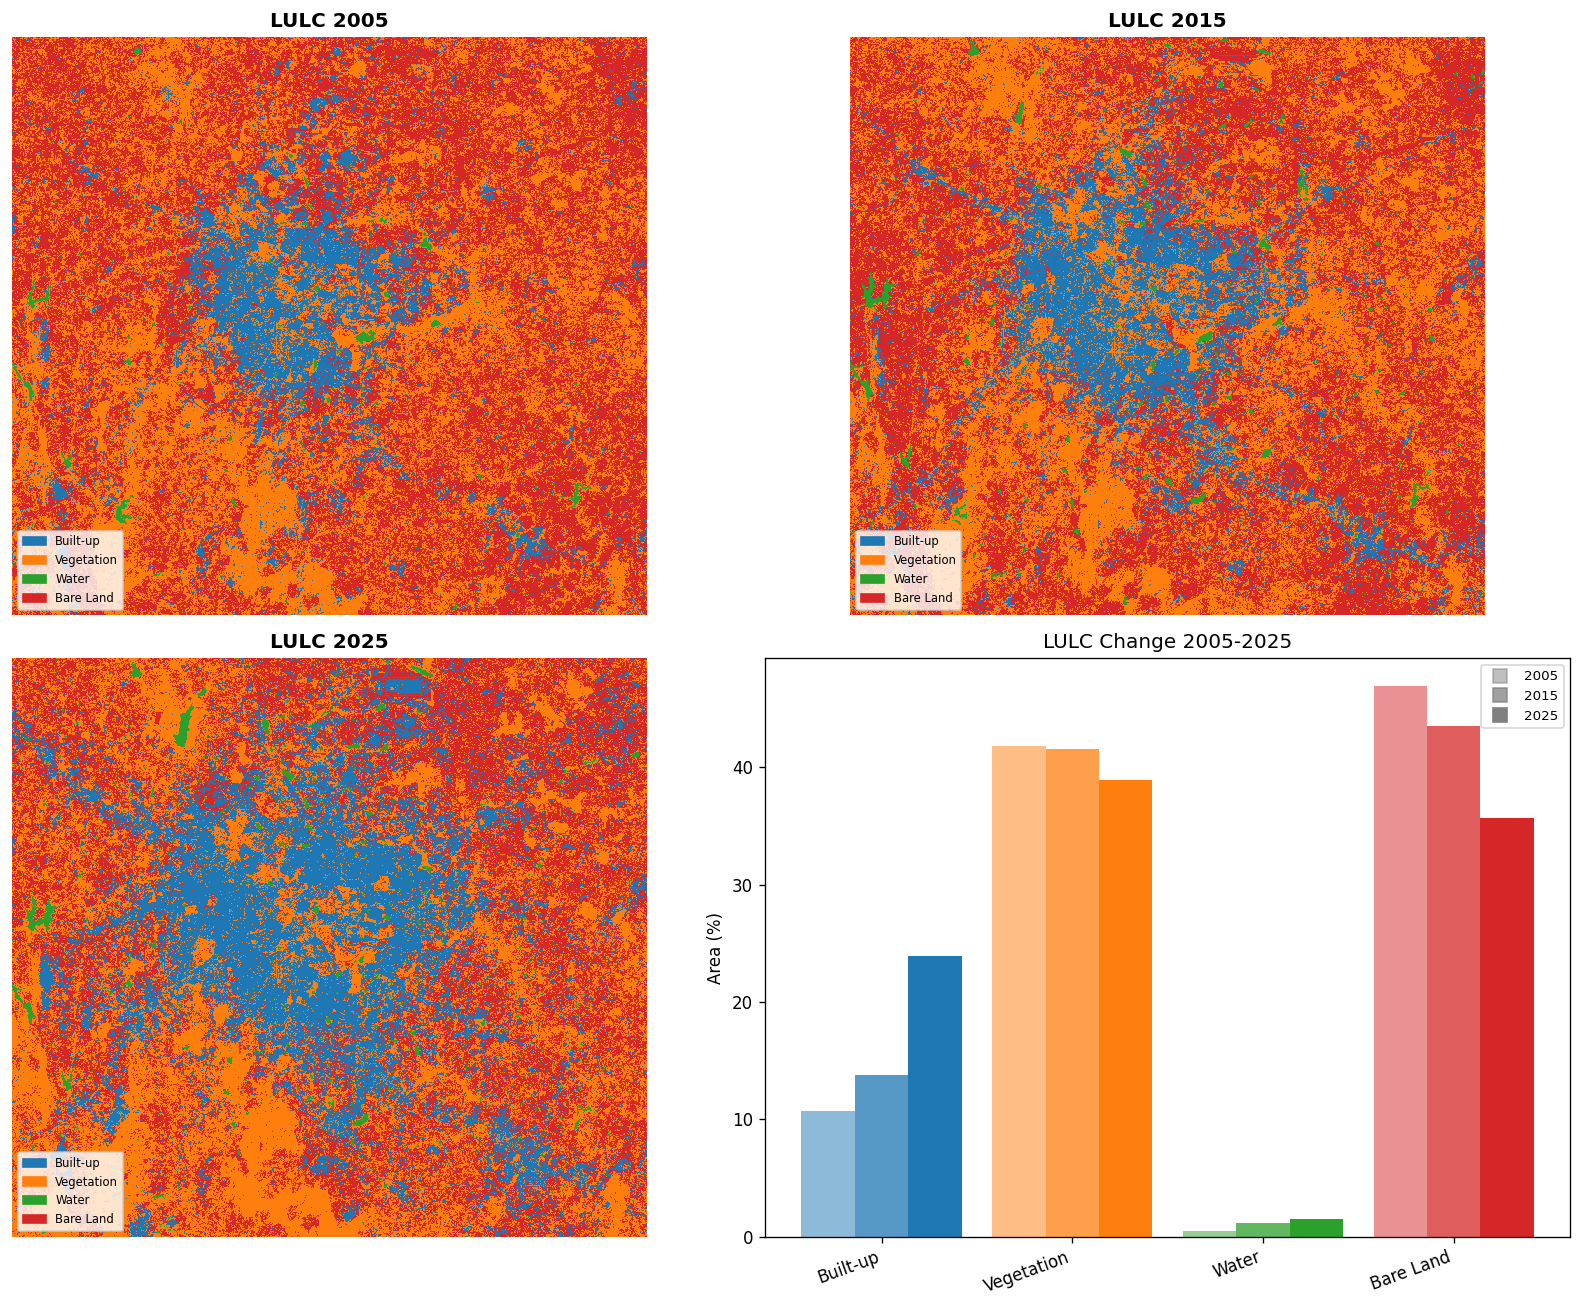

In [10]:
COLORS = plt.cm.tab10.colors
cmap   = mcolors.ListedColormap([COLORS[i % 10] for i in range(N_CLASSES)])
bounds = CLASS_IDS + [max(CLASS_IDS)+1]
norm_c = mcolors.BoundaryNorm(bounds, cmap.N)
legend_patches = [Patch(color=COLORS[i], label=CLASS_MAP[c]) for i, c in enumerate(CLASS_IDS)]

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (lulc, yr) in zip(axes.flatten()[:3], [(L05,'2005'),(L15,'2015'),(L25,'2025')]):
    disp = lulc.astype(float); disp[~valid_mask] = np.nan
    ax.imshow(disp, cmap=cmap, norm=norm_c, interpolation='nearest')
    ax.set_title(f'LULC {yr}', fontweight='bold'); ax.axis('off')
    ax.legend(handles=legend_patches, loc='lower left', fontsize=7, framealpha=0.8)

ax = axes[1][1]
x = np.arange(len(CLASS_MAP)); w = 0.28
for i, (cls, name) in enumerate(CLASS_MAP.items()):
    pcts = [stats_05[name]['pct'], stats_15[name]['pct'], stats_25[name]['pct']]
    ax.bar(x[i]-w, pcts[0], w, color=COLORS[i], alpha=0.5, label=f'{name}')
    ax.bar(x[i],   pcts[1], w, color=COLORS[i], alpha=0.75)
    ax.bar(x[i]+w, pcts[2], w, color=COLORS[i], alpha=1.0)
ax.set_xticks(x); ax.set_xticklabels(list(CLASS_MAP.values()), rotation=20, ha='right')
ax.set_ylabel('Area (%)'); ax.set_title('LULC Change 2005-2025')
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0],color='gray',lw=0,marker='s',ms=8,alpha=a,label=yr)
                   for a,yr in [(0.5,'2005'),(0.75,'2015'),(1.0,'2025')]], fontsize=8)
plt.tight_layout()
plt.savefig('lulc_change_maps.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Transition Probability Matrix (Markov)


Transition Matrix 2005-2015:
            Built-up  Vegetation  Water  Bare Land
Built-up       0.650       0.120  0.010      0.221
Vegetation     0.054       0.685  0.009      0.252
Water          0.019       0.192  0.756      0.033
Bare Land      0.098       0.244  0.006      0.652

Transition Matrix 2015-2025:
            Built-up  Vegetation  Water  Bare Land
Built-up       0.752       0.118  0.010      0.120
Vegetation     0.103       0.630  0.009      0.259
Water          0.029       0.282  0.596      0.093
Bare Land      0.212       0.248  0.007      0.533

Transition Matrix 2005-2025:
            Built-up  Vegetation  Water  Bare Land
Built-up       0.724       0.134  0.015      0.127
Vegetation     0.137       0.576  0.014      0.273
Water          0.025       0.349  0.593      0.033
Bare Land      0.222       0.281  0.010      0.487


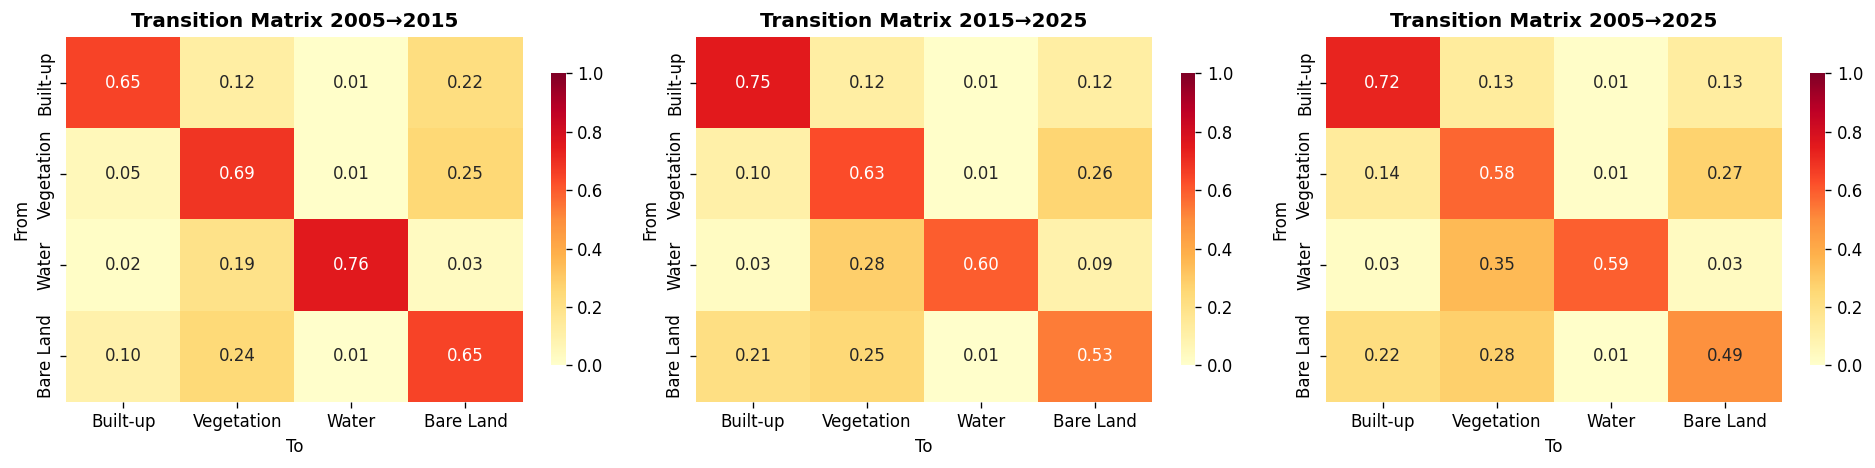

In [11]:
def transition_matrix(lulc_t1, lulc_t2, class_ids, mask):
    n = len(class_ids)
    counts = np.zeros((n, n), dtype=np.float64)
    m = mask & (lulc_t1 > 0) & (lulc_t2 > 0)
    for i, c1 in enumerate(class_ids):
        sub = lulc_t2[m & (lulc_t1 == c1)]
        for j, c2 in enumerate(class_ids):
            counts[i, j] = (sub == c2).sum()
    row_sums = counts.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return counts / row_sums

T_05_15 = transition_matrix(L05, L15, CLASS_IDS, valid_mask)
T_15_25 = transition_matrix(L15, L25, CLASS_IDS, valid_mask)
T_05_25 = transition_matrix(L05, L25, CLASS_IDS, valid_mask)

labels = list(CLASS_MAP.values())
for T, period in [(T_05_15,'2005-2015'), (T_15_25,'2015-2025'), (T_05_25,'2005-2025')]:
    df = pd.DataFrame(T, index=labels, columns=labels)
    print(f'\nTransition Matrix {period}:')
    print(df.round(3).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (T, period) in zip(axes, [(T_05_15,'2005→2015'),(T_15_25,'2015→2025'),(T_05_25,'2005→2025')]):
    sns.heatmap(T, annot=True, fmt='.2f', xticklabels=labels, yticklabels=labels,
                cmap='YlOrRd', ax=ax, vmin=0, vmax=1, cbar_kws={'shrink':0.8})
    ax.set_title(f'Transition Matrix {period}', fontweight='bold')
    ax.set_xlabel('To'); ax.set_ylabel('From')
plt.tight_layout()
plt.savefig('transition_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Driver Variable Analysis (Pearson Correlation)

Pearson correlation with LULC Change (|r| ranked):
Dist_PrimaryRoad      -0.0938
Dist_SecondaryRoad    -0.0882
Dist_RoadNetwork      -0.0746
Dist_Waterbody        -0.0703
Dist_RailwayStation   -0.0627
Elevation              0.0620
Dist_Metro            -0.0589
Slope                 -0.0573


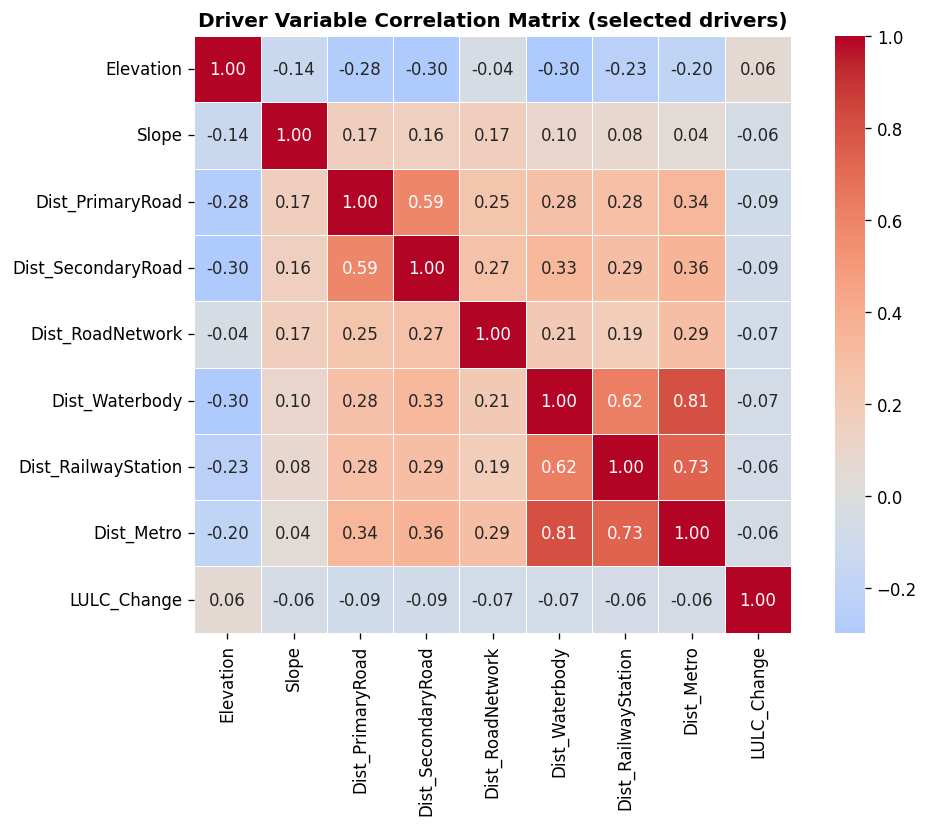

In [12]:
driver_sample = np.column_stack([v.ravel()[idx_sample] for v in selected_drivers.values()])
lulc_change_vec = (L25.ravel()[idx_sample] != L05.ravel()[idx_sample]).astype(float)

corr_df = pd.DataFrame(driver_sample, columns=list(selected_drivers.keys()))
corr_df['LULC_Change'] = lulc_change_vec

corr = corr_df.corr()
print('Pearson correlation with LULC Change (|r| ranked):')
print(corr['LULC_Change'].drop('LULC_Change').sort_values(key=abs, ascending=False).round(4).to_string())

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, center=0,
            square=True, linewidths=0.5)
ax.set_title('Driver Variable Correlation Matrix (selected drivers)', fontweight='bold')
plt.tight_layout()
plt.savefig('driver_correlation.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Stacked Ensemble: Random Forest + MLP (Improved ANN)

**Why stacking?**  
- Random Forest captures non-linear spatial patterns and is robust to noise  
- MLP (ANN) learns deep feature interactions like the original paper  
- Logistic Regression meta-learner combines their outputs optimally  
- This addresses the 57% allocation disagreement in the baseline by providing
  much better transition potential estimates


In [13]:
SAMPLES_PER_CLASS = 15_000
rng = np.random.default_rng(42)

def stratified_spatial_sample(lulc_arr, driver_X, valid_idx, class_ids,
                               n_per_class=15000, n_blocks=8, seed=42):
    # Spatially-stratified sampling: divide image into n_blocks x n_blocks grid,
    # sample proportionally from each block so all landscape regions are covered.
    rng_local = np.random.default_rng(seed)
    r, c = lulc_arr.shape
    block_r = r // n_blocks
    block_c = c // n_blocks

    selected = []
    y_flat = lulc_arr.ravel()

    for cid in class_ids:
        cls_mask_flat = (y_flat == cid)
        cls_pool = []

        for bi in range(n_blocks):
            for bj in range(n_blocks):
                r0, r1 = bi * block_r, min((bi+1) * block_r, r)
                c0, c1 = bj * block_c, min((bj+1) * block_c, c)
                block_rows = np.arange(r0, r1)
                block_cols = np.arange(c0, c1)
                block_idx  = (block_rows[:, None] * c + block_cols[None, :]).ravel()
                in_block = cls_mask_flat[block_idx]
                cls_in_block = block_idx[in_block]
                cls_pool.append(cls_in_block)

        cls_pool = np.concatenate(cls_pool)
        cls_pool = np.intersect1d(cls_pool, valid_idx)
        if len(cls_pool) == 0:
            continue
        n = min(n_per_class, len(cls_pool))
        chosen = rng_local.choice(cls_pool, size=n, replace=False)
        selected.append(chosen)
        print(f'  Class {cid} ({CLASS_MAP[cid]}): sampled {n:,} pixels (pool={len(cls_pool):,})')

    return np.concatenate(selected)

print('Building features for 2005 to 2015 training...')
X_full, valid_idx = build_features_v2(L05, selected_drivers, valid_mask)
y_full = L15.ravel()

print('Spatially-stratified sampling (2005 to 2015):')
train_flat_idx = stratified_spatial_sample(L15, X_full, valid_idx, CLASS_IDS,
                                            n_per_class=SAMPLES_PER_CLASS)
rng.shuffle(train_flat_idx)

X_train = X_full[train_flat_idx]
y_train  = y_full[train_flat_idx]

keep = y_train > 0
X_train, y_train = X_train[keep], y_train[keep]
print(f'Final training set: {len(X_train):,} samples, {X_train.shape[1]} features')
print(f'Class dist: {dict(zip(*np.unique(y_train, return_counts=True)))}')


Building features for 2005 to 2015 training...
Spatially-stratified sampling (2005 to 2015):
  Class 1 (Built-up): sampled 15,000 pixels (pool=645,582)
  Class 2 (Vegetation): sampled 15,000 pixels (pool=1,940,078)
  Class 3 (Water): sampled 15,000 pixels (pool=55,758)
  Class 4 (Bare Land): sampled 15,000 pixels (pool=2,031,478)
Final training set: 60,000 samples, 20 features
Class dist: {np.int16(1): np.int64(15000), np.int16(2): np.int64(15000), np.int16(3): np.int64(15000), np.int16(4): np.int64(15000)}


In [14]:
# ── Fit scaler (StandardScaler works better than MinMax for stacking) ──
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)

# ── Full valid set for evaluation ──
X_valid   = X_full[valid_idx]
y_valid   = y_full[valid_idx]
keep_v    = y_valid > 0
X_valid   = X_valid[keep_v]
y_valid   = y_valid[keep_v]
valid_idx_keep = valid_idx[keep_v]
X_valid_sc = scaler.transform(X_valid)

# ── IMPROVEMENT 4: Stacked Ensemble ──
# Base estimators chosen to complement each other:
# RF = strong spatial / tree-based signal
# MLP = deep non-linear ANN (mirrors paper architecture)
# Meta = LogisticRegression for calibrated probability combination

base_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=18,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
)

base_mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32),   # deeper than original
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    alpha=1e-4,                               # L2 regularisation
    batch_size=512,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
    verbose=False,
)

meta_lr = LogisticRegression(C=1.0, max_iter=500, random_state=42)

stacked = StackingClassifier(
    estimators=[('rf', base_rf), ('mlp', base_mlp)],
    final_estimator=meta_lr,
    cv=5,                      # internal 5-fold to build meta-features
    passthrough=False,
    n_jobs=-1,
)

print('Training stacked ensemble (RF + MLP → LogReg meta-learner)...')
print('This takes a few minutes...')
t0 = time.time()
stacked.fit(X_train_sc, y_train)
print(f'Done in {time.time()-t0:.1f}s')


Training stacked ensemble (RF + MLP → LogReg meta-learner)...
This takes a few minutes...
Done in 117.0s


In [15]:
# ── 5-fold cross-validation kappa ──
print('5-fold cross-validation on training set...')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
kappas = []
for fold, (tr, te) in enumerate(skf.split(X_train_sc, y_train)):
    pred = stacked.predict(X_train_sc[te])
    k = cohen_kappa_score(y_train[te], pred)
    kappas.append(k)
    print(f'  Fold {fold+1}: κ={k:.4f}')
print(f'Mean CV Kappa: {np.mean(kappas):.4f} ± {np.std(kappas):.4f}')


5-fold cross-validation on training set...
  Fold 1: κ=0.7698
  Fold 2: κ=0.7746
  Fold 3: κ=0.7742
  Fold 4: κ=0.7802
  Fold 5: κ=0.7651
Mean CV Kappa: 0.7728 ± 0.0051


## 7. Improved CA-ANN Simulation Functions

**Key improvements over baseline CA:**
1. **Persistence bonus** — stable land covers (water, built-up) are harder to convert
2. **Adjacency constraint** — new built-up can only grow near existing built-up (prevents teleportation)
3. **Iterative Markov demand** — demand re-calculated each step, not just at start
4. **Soft stochastic allocation** — rank-based probabilistic selection prevents deterministic over-concentration


In [16]:
PERSISTENCE_WEIGHT = {
    1: 0.15,   # Built-up  — high inertia
    2: 0.05,   # Vegetation
    3: 0.20,   # Water — very stable
    4: 0.02,   # Bare Land — most dynamic
}

def predict_transition_potential(model, scaler, sel_drivers, lulc_current, mask, batch=50_000):
    # Predict class probabilities for every valid pixel
    X_f, vidx = build_features_v2(lulc_current, sel_drivers, mask)
    X_v = scaler.transform(X_f[vidx])
    proba_list = []
    for i in range(0, len(X_v), batch):
        proba_list.append(model.predict_proba(X_v[i:i+batch]))
    proba = np.vstack(proba_list)
    full  = np.zeros((lulc_current.size, len(model.classes_)), dtype=np.float32)
    full[vidx] = proba
    return full.reshape(lulc_current.shape[0], lulc_current.shape[1], -1)

def markov_demand_1step(lulc_t1, trans_matrix, class_ids, mask):
    # Expected pixel count of each class after 1 Markov step
    current = np.array([(lulc_t1[mask] == cid).sum() for cid in class_ids], dtype=float)
    future  = current @ trans_matrix
    return {cid: int(future[i]) for i, cid in enumerate(class_ids)}

def build_adjacency_map(lulc_arr, target_class, radius=3):
    # Binary map: 1 where target_class exists within radius pixels
    binary   = (lulc_arr == target_class).astype(np.float32)
    expanded = uniform_filter(binary, size=2*radius+1, mode='reflect')
    return (expanded > 0).astype(np.float32)

def ca_ann_simulate_v2(lulc_current, sel_drivers, model, scaler,
                        trans_matrix, class_ids, mask,
                        n_steps=10, random_seed=42,
                        adjacency_class=1, adjacency_radius=5,
                        stochastic_fraction=0.1):
    # Improved CA-ANN simulation with per-step Markov demand,
    # persistence bonus, adjacency constraint, and stochastic allocation
    rng = np.random.default_rng(random_seed)
    lulc_sim = lulc_current.copy()
    cls_idx_map = {cid: i for i, cid in enumerate(model.classes_)}

    for step in range(n_steps):
        pot = predict_transition_potential(model, scaler, sel_drivers, lulc_sim, mask)

        target        = markov_demand_1step(lulc_sim, trans_matrix, class_ids, mask)
        current_count = {cid: (lulc_sim[mask] == cid).sum() for cid in class_ids}

        new_lulc = lulc_sim.copy()
        adj_map  = build_adjacency_map(lulc_sim, adjacency_class, radius=adjacency_radius)

        change_needed = {cid: target[cid] - current_count[cid] for cid in class_ids}
        for cid in sorted(class_ids, key=lambda c: -max(change_needed[c], 0)):
            needed = change_needed[cid]
            if needed <= 0:
                continue
            ci = cls_idx_map.get(cid)
            if ci is None:
                continue

            suit = pot[:, :, ci].copy()

            # Persistence bonus
            suit += PERSISTENCE_WEIGHT.get(cid, 0) * (lulc_sim == cid).astype(np.float32)

            # Adjacency constraint for built-up
            if cid == adjacency_class:
                suit *= adj_map

            suit[lulc_sim == cid] = -1
            suit[~mask] = -1

            valid_suit = suit[mask & (suit >= 0)]
            if len(valid_suit) == 0:
                continue
            noise_scale = stochastic_fraction * (valid_suit.max() - valid_suit.min() + 1e-6)
            noise = rng.uniform(0, noise_scale, size=mask.shape)
            suit[mask] += noise[mask]

            flat     = suit.ravel()
            n_change = min(needed, int((flat > 0).sum()))
            if n_change <= 0:
                continue

            top_idx = np.argpartition(flat, -n_change)[-n_change:]
            new_lulc.ravel()[top_idx] = cid

        lulc_sim = new_lulc
        if (step + 1) % 2 == 0 or step == 0:
            built_pct = (lulc_sim[mask] == 1).mean() * 100
            print(f'  Step {step+1}/{n_steps} | Built-up: {built_pct:.1f}%')

    return lulc_sim

print('CA-ANN v2 functions defined.')


CA-ANN v2 functions defined.


## 8. Calibration: Simulate 2015 from 2005

In [17]:
print('=== CALIBRATION: Simulating 2015 from 2005 ===')
L15_sim = ca_ann_simulate_v2(
    lulc_current=L05,
    sel_drivers=selected_drivers,
    model=stacked,
    scaler=scaler,
    trans_matrix=T_05_15,
    class_ids=CLASS_IDS,
    mask=valid_mask,
    n_steps=10,
    random_seed=42,
    adjacency_class=1,
    adjacency_radius=5,
    stochastic_fraction=0.08,
)
print('\nCalibration simulation complete.')


=== CALIBRATION: Simulating 2015 from 2005 ===
  Step 1/10 | Built-up: 13.7%
  Step 2/10 | Built-up: 15.4%
  Step 4/10 | Built-up: 16.8%
  Step 6/10 | Built-up: 17.3%
  Step 8/10 | Built-up: 17.4%
  Step 10/10 | Built-up: 17.4%

Calibration simulation complete.


## 9. Validation — Pontius & Millones (2011) Quantity & Allocation Disagreement

In [18]:
def pontius_millones_accuracy(reference, simulated, class_ids, mask):
    ref = reference[mask].ravel()
    sim = simulated[mask].ravel()
    keep = (ref > 0) & (sim > 0)
    ref, sim = ref[keep], sim[keep]
    n = len(ref)
    results = {}
    total_qd = total_ad = 0
    for g in class_ids:
        p_ref_g = (ref == g).sum() / n
        p_sim_g = (sim == g).sum() / n
        p_gg    = ((ref == g) & (sim == g)).sum() / n
        qg = abs(p_ref_g - p_sim_g)
        ag = 2 * min(p_ref_g - p_gg, p_sim_g - p_gg)
        results[CLASS_MAP[g]] = {
            'Quantity Disagreement (%)': qg * 100,
            'Allocation Disagreement (%)': ag * 100,
            'Total Disagreement (%)': (qg + ag) * 100
        }
        total_qd += qg
        total_ad += ag
    overall_agree = (ref == sim).sum() / n * 100
    kappa = cohen_kappa_score(ref, sim)
    return results, overall_agree, kappa, total_qd * 100, total_ad * 100

pm_res, oa, kappa, total_qd, total_ad = pontius_millones_accuracy(
    L15, L15_sim, CLASS_IDS, valid_mask)

print('=' * 60)
print('CALIBRATION VALIDATION (Simulated 2015 vs Observed 2015):')
print(f'  Overall Agreement      : {oa:.2f}%')
print(f'  Kappa                  : {kappa:.4f}')
print(f'  Quantity Disagreement  : {total_qd:.2f}%')
print(f'  Allocation Disagreement: {total_ad:.2f}%')
print()
print(pd.DataFrame(pm_res).T.round(3).to_string())


CALIBRATION VALIDATION (Simulated 2015 vs Observed 2015):
  Overall Agreement      : 66.96%
  Kappa                  : 0.4816
  Quantity Disagreement  : 10.95%
  Allocation Disagreement: 55.14%

            Quantity Disagreement (%)  Allocation Disagreement (%)  Total Disagreement (%)
Built-up                        3.601                        7.227                  10.828
Vegetation                      2.060                       23.715                  25.775
Water                           1.873                        0.357                   2.230
Bare Land                       3.414                       23.839                  27.254


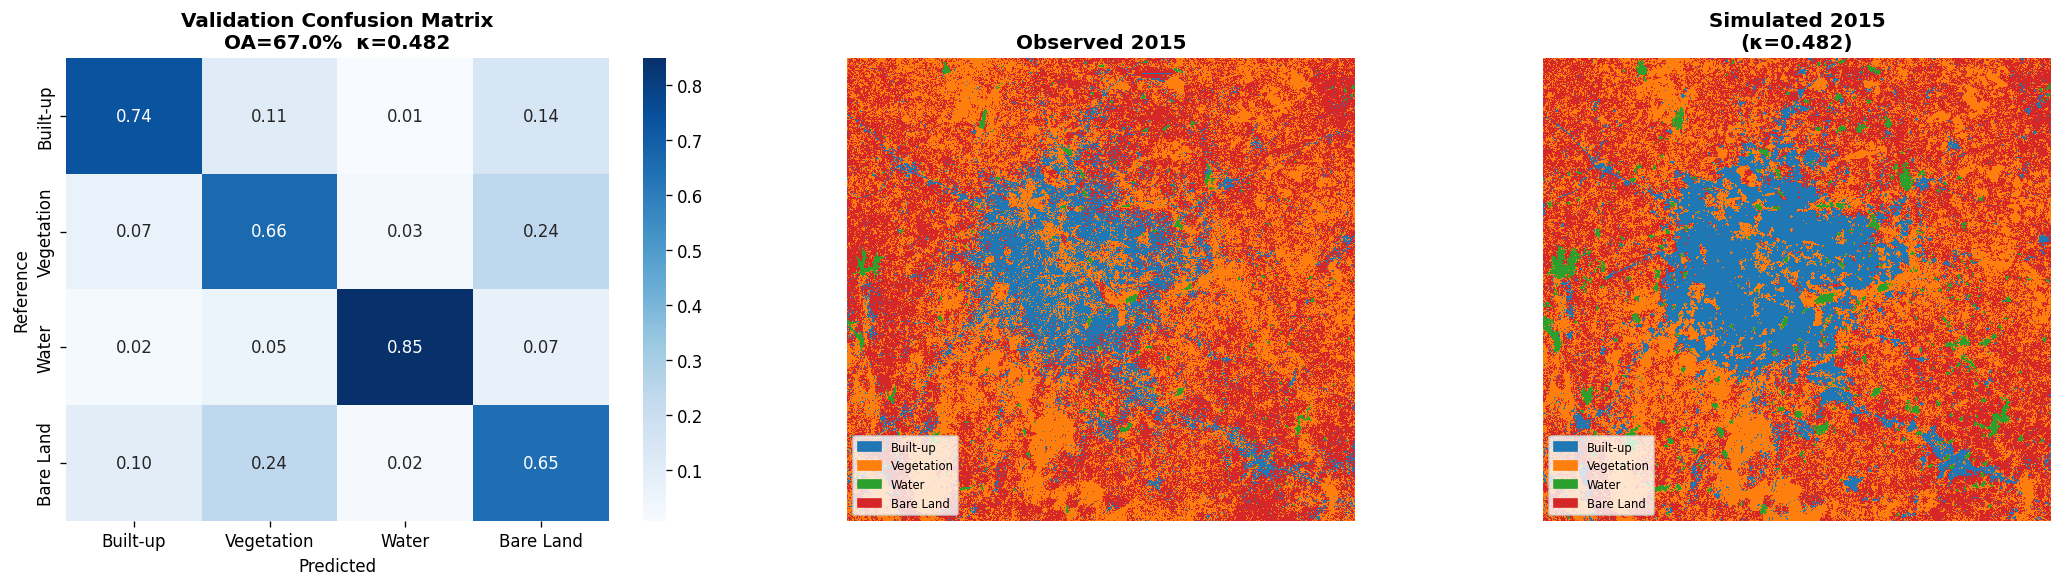

              precision    recall  f1-score   support

    Built-up       0.58      0.74      0.65    646342
  Vegetation       0.70      0.66      0.68   1947682
       Water       0.33      0.85      0.48     55788
   Bare Land       0.70      0.65      0.67   2040412

    accuracy                           0.67   4690224
   macro avg       0.58      0.73      0.62   4690224
weighted avg       0.68      0.67      0.67   4690224



In [19]:
# ── Confusion matrix ──
ref_flat = L15[valid_mask].ravel()
sim_flat = L15_sim[valid_mask].ravel()
keep = (ref_flat > 0) & (sim_flat > 0)
cm = confusion_matrix(ref_flat[keep], sim_flat[keep], labels=CLASS_IDS, normalize='true')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='.2f', xticklabels=labels, yticklabels=labels,
            cmap='Blues', ax=axes[0])
axes[0].set_title(f'Validation Confusion Matrix\nOA={oa:.1f}%  κ={kappa:.3f}', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Reference')

# Observed 2015
disp = L15.astype(float); disp[~valid_mask] = np.nan
axes[1].imshow(disp, cmap=cmap, norm=norm_c, interpolation='nearest')
axes[1].set_title('Observed 2015', fontweight='bold'); axes[1].axis('off')
axes[1].legend(handles=legend_patches, loc='lower left', fontsize=7)

# Simulated 2015
disp = L15_sim.astype(float); disp[~valid_mask] = np.nan
axes[2].imshow(disp, cmap=cmap, norm=norm_c, interpolation='nearest')
axes[2].set_title(f'Simulated 2015\n(κ={kappa:.3f})', fontweight='bold'); axes[2].axis('off')
axes[2].legend(handles=legend_patches, loc='lower left', fontsize=7)

plt.tight_layout()
plt.savefig('validation_2015.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(ref_flat[keep], sim_flat[keep],
                             labels=CLASS_IDS, target_names=labels, zero_division=0))


## 10. Retrain on 2015→2025 for Future Projections

**Two-phase training strategy:**  
Phase 1 (above): 2005→2015 for calibration/validation  
Phase 2 (here): 2015→2025 for final model — captures most recent dynamics (urban sprawl acceleration)


In [20]:
print('Building features for 2015→2025 (final model)...')
X_full2, valid_idx2 = build_features_v2(L15, selected_drivers, valid_mask)
y_full2 = L25.ravel()

print('\nSpatially-stratified sampling (2015→2025):')
train_flat_idx2 = stratified_spatial_sample(L25, X_full2, valid_idx2, CLASS_IDS,
                                             n_per_class=SAMPLES_PER_CLASS)
rng.shuffle(train_flat_idx2)

X_tr2 = X_full2[train_flat_idx2]
y_tr2  = y_full2[train_flat_idx2]
keep2  = y_tr2 > 0
X_tr2, y_tr2 = X_tr2[keep2], y_tr2[keep2]

scaler2 = StandardScaler()
X_tr2_sc = scaler2.fit_transform(X_tr2)

# ── Final stacked model (same architecture) ──
base_rf2 = RandomForestClassifier(
    n_estimators=200, max_depth=18, min_samples_leaf=5,
    max_features='sqrt', class_weight='balanced', n_jobs=-1, random_state=42)
base_mlp2 = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64, 32), activation='relu', solver='adam',
    learning_rate_init=0.001, alpha=1e-4, batch_size=512,
    max_iter=500, early_stopping=True, validation_fraction=0.1,
    n_iter_no_change=15, random_state=42, verbose=False)
meta_lr2  = LogisticRegression(C=1.0, max_iter=500, random_state=42)

stacked2 = StackingClassifier(
    estimators=[('rf', base_rf2), ('mlp', base_mlp2)],
    final_estimator=meta_lr2, cv=5, passthrough=False, n_jobs=-1)

print('Training final ensemble on 2015→2025...')
t0 = time.time()
stacked2.fit(X_tr2_sc, y_tr2)
print(f'Done in {time.time()-t0:.1f}s')


Building features for 2015→2025 (final model)...

Spatially-stratified sampling (2015→2025):
  Class 1 (Built-up): sampled 15,000 pixels (pool=1,119,542)
  Class 2 (Vegetation): sampled 15,000 pixels (pool=1,816,173)
  Class 3 (Water): sampled 15,000 pixels (pool=70,954)
  Class 4 (Bare Land): sampled 15,000 pixels (pool=1,666,227)
Training final ensemble on 2015→2025...
Done in 202.2s


## 11. Future Projections: 2035 & 2045

In [21]:
print('=== PROJECTING 2035 (10 steps from 2025) ===')
L35_sim = ca_ann_simulate_v2(
    lulc_current=L25,
    sel_drivers=selected_drivers,
    model=stacked2,
    scaler=scaler2,
    trans_matrix=T_15_25,
    class_ids=CLASS_IDS,
    mask=valid_mask,
    n_steps=10,
    random_seed=42,
    adjacency_class=1,
    adjacency_radius=5,
    stochastic_fraction=0.08,
)

print('\n=== PROJECTING 2045 (10 steps from 2035) ===')
L45_sim = ca_ann_simulate_v2(
    lulc_current=L35_sim,
    sel_drivers=selected_drivers,
    model=stacked2,
    scaler=scaler2,
    trans_matrix=T_15_25,
    class_ids=CLASS_IDS,
    mask=valid_mask,
    n_steps=10,
    random_seed=42,
    adjacency_class=1,
    adjacency_radius=5,
    stochastic_fraction=0.08,
)
print('\nProjections complete.')


=== PROJECTING 2035 (10 steps from 2025) ===
  Step 1/10 | Built-up: 29.5%
  Step 2/10 | Built-up: 32.7%
  Step 4/10 | Built-up: 35.6%
  Step 6/10 | Built-up: 36.7%
  Step 8/10 | Built-up: 37.2%
  Step 10/10 | Built-up: 37.4%

=== PROJECTING 2045 (10 steps from 2035) ===
  Step 1/10 | Built-up: 37.5%
  Step 2/10 | Built-up: 37.5%
  Step 4/10 | Built-up: 37.5%
  Step 6/10 | Built-up: 37.6%
  Step 8/10 | Built-up: 37.6%
  Step 10/10 | Built-up: 37.6%

Projections complete.


## 12. Future Projections Analysis & Visualisation

In [22]:
stats_35 = area_stats(L35_sim, valid_mask, CLASS_MAP, PIXEL_AREA_HA)
stats_45 = area_stats(L45_sim, valid_mask, CLASS_MAP, PIXEL_AREA_HA)

df_future = pd.DataFrame({
    '2025 (ha)':     {k: v['ha'] for k,v in stats_25.items()},
    '2035 sim (ha)': {k: v['ha'] for k,v in stats_35.items()},
    '2045 sim (ha)': {k: v['ha'] for k,v in stats_45.items()},
    '2025 (%)':      {k: v['pct'] for k,v in stats_25.items()},
    '2035 sim (%)':  {k: v['pct'] for k,v in stats_35.items()},
    '2045 sim (%)':  {k: v['pct'] for k,v in stats_45.items()},
})
print('Future Projection Statistics:')
print(df_future.round(2).to_string())

dd_25_35, dd_35_45, dd_25_45 = {}, {}, {}
for cls in CLASS_MAP.values():
    a25=stats_25[cls]['ha']; a35=stats_35[cls]['ha']; a45=stats_45[cls]['ha']
    dd_25_35[cls] = dynamic_degree(a25, a35, 10)
    dd_35_45[cls] = dynamic_degree(a35, a45, 10)
    dd_25_45[cls] = dynamic_degree(a25, a45, 20)

df_dd = pd.DataFrame({'DD 25-35 (%/yr)': dd_25_35,
                       'DD 35-45 (%/yr)': dd_35_45,
                       'DD 25-45 (%/yr)': dd_25_45})
print('\nProjected Annual Rate of Change:')
print(df_dd.round(3).to_string())


Future Projection Statistics:
            2025 (ha)  2035 sim (ha)  2045 sim (ha)  2025 (%)  2035 sim (%)  2045 sim (%)
Built-up    100881.09      157873.77      158581.62     23.90         37.40         37.57
Vegetation  164238.93      137215.44      136454.13     38.91         32.51         32.33
Water         6390.45        9025.65        9051.21      1.51          2.14          2.14
Bare Land   150609.69      118005.30      118033.20     35.68         27.96         27.96

Projected Annual Rate of Change:
            DD 25-35 (%/yr)  DD 35-45 (%/yr)  DD 25-45 (%/yr)
Built-up              5.649            0.045            2.860
Vegetation           -1.645           -0.055           -0.846
Water                 4.124            0.028            2.082
Bare Land            -2.165            0.002           -1.081


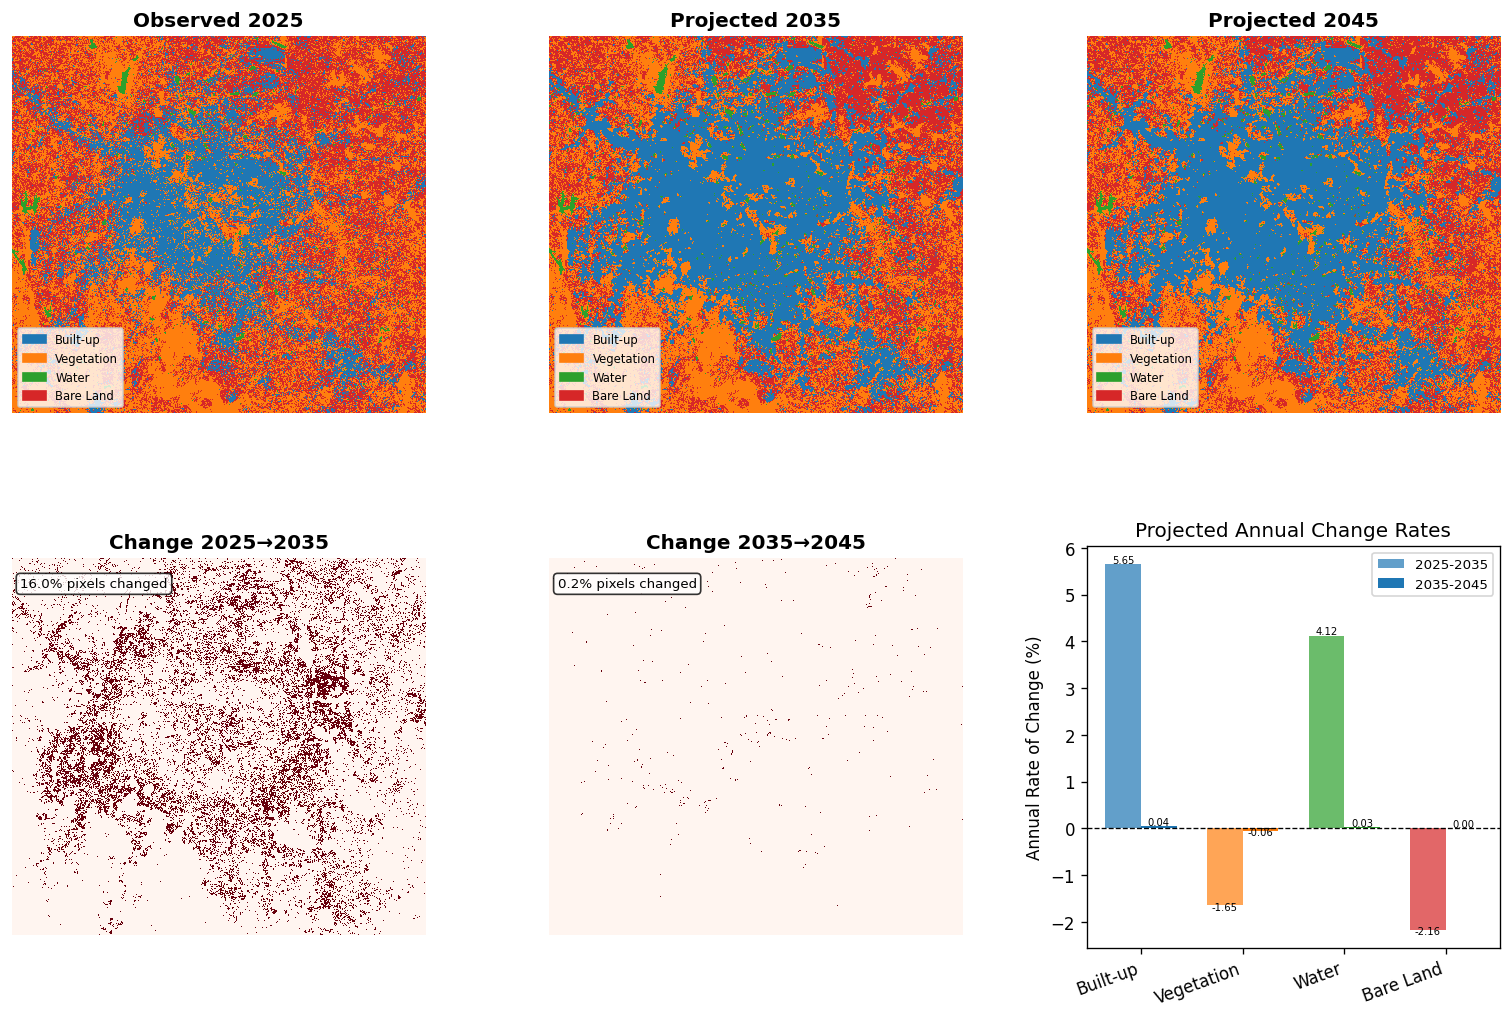

In [23]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

for idx, (arr, title) in enumerate([(L25,'Observed 2025'),(L35_sim,'Projected 2035'),(L45_sim,'Projected 2045')]):
    ax = fig.add_subplot(gs[0, idx])
    disp = arr.astype(float); disp[~valid_mask] = np.nan
    ax.imshow(disp, cmap=cmap, norm=norm_c, interpolation='nearest')
    ax.set_title(title, fontweight='bold'); ax.axis('off')
    ax.legend(handles=legend_patches, loc='lower left', fontsize=7, framealpha=0.8)

for idx, (base, proj, title) in enumerate(
        [(L25, L35_sim,'Change 2025→2035'), (L35_sim, L45_sim,'Change 2035→2045')]):
    ax = fig.add_subplot(gs[1, idx])
    change = np.zeros_like(base, dtype=float)
    change[valid_mask & (base != proj)] = 1
    change[~valid_mask] = np.nan
    im = ax.imshow(change, cmap='Reds', vmin=0, vmax=1, interpolation='nearest')
    ax.set_title(title, fontweight='bold'); ax.axis('off')
    pct = change[valid_mask].mean() * 100
    ax.text(0.02, 0.95, f'{pct:.1f}% pixels changed',
            transform=ax.transAxes, fontsize=8, va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax = fig.add_subplot(gs[1, 2])
x = np.arange(N_CLASSES); w = 0.35
b1 = ax.bar(x-w/2, [dd_25_35[c] for c in CLASS_MAP.values()], w,
            color=[COLORS[i] for i in range(N_CLASSES)], alpha=0.7, label='2025-2035')
b2 = ax.bar(x+w/2, [dd_35_45[c] for c in CLASS_MAP.values()], w,
            color=[COLORS[i] for i in range(N_CLASSES)], alpha=1.0, label='2035-2045')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x); ax.set_xticklabels(list(CLASS_MAP.values()), rotation=20, ha='right')
ax.set_ylabel('Annual Rate of Change (%)'); ax.set_title('Projected Annual Change Rates')
ax.legend(fontsize=8)
for bar in list(b1)+list(b2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+(0.02 if h>=0 else -0.1),
            f'{h:.2f}', ha='center', fontsize=6)

plt.savefig('projected_lulc_2035_2045.png', dpi=150, bbox_inches='tight')
plt.show()


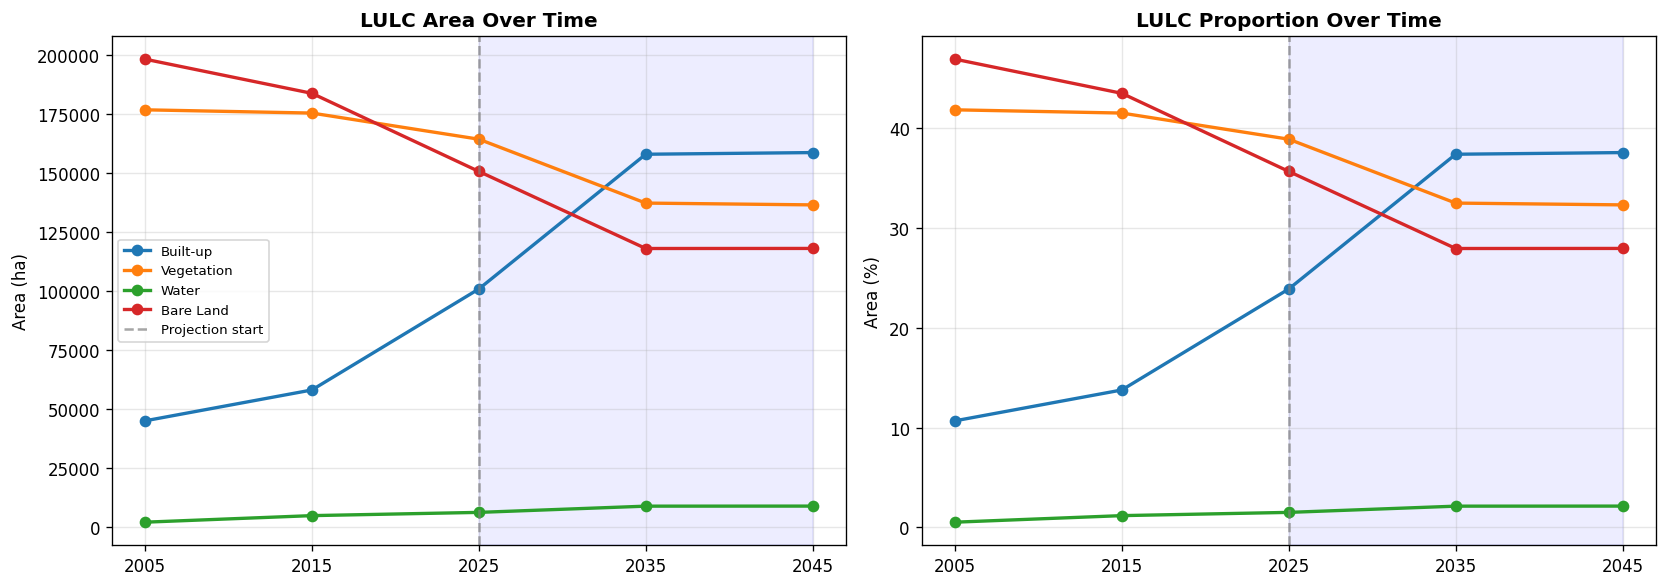

In [24]:
years = [2005, 2015, 2025, 2035, 2045]
all_stats = [stats_05, stats_15, stats_25, stats_35, stats_45]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for i, (cid, cname) in enumerate(CLASS_MAP.items()):
    areas = [s[cname]['ha'] for s in all_stats]
    pcts  = [s[cname]['pct'] for s in all_stats]
    ax1.plot(years, areas, marker='o', color=COLORS[i], label=cname, linewidth=2)
    ax2.plot(years, pcts,  marker='o', color=COLORS[i], label=cname, linewidth=2)

for ax in [ax1, ax2]:
    ax.axvline(2025, color='gray', linestyle='--', alpha=0.7, label='Projection start')
    ax.axvspan(2025, 2045, alpha=0.07, color='blue')
    ax.set_xticks(years); ax.grid(alpha=0.3)
ax1.set_ylabel('Area (ha)'); ax1.set_title('LULC Area Over Time', fontweight='bold'); ax1.legend(fontsize=8)
ax2.set_ylabel('Area (%)'); ax2.set_title('LULC Proportion Over Time', fontweight='bold')
plt.tight_layout()
plt.savefig('lulc_timeline.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Driver Variable Importance

Feature importances (RF Gini):
            Feature  Importance
       Neigh5_Water      0.1018
   Neigh11_Built-up      0.0830
       Neigh3_Water      0.0725
      Neigh11_Water      0.0705
     Dist_Waterbody      0.0689
         Dist_Metro      0.0540
          Elevation      0.0503
   Dist_RoadNetwork      0.0498
    Neigh5_Built-up      0.0497
Dist_RailwayStation      0.0428
  Neigh3_Vegetation      0.0401
   Dist_PrimaryRoad      0.0394
 Neigh11_Vegetation      0.0390
  Neigh11_Bare Land      0.0382
 Dist_SecondaryRoad      0.0382
  Neigh5_Vegetation      0.0366
    Neigh3_Built-up      0.0354
              Slope      0.0346
   Neigh5_Bare Land      0.0288
   Neigh3_Bare Land      0.0265


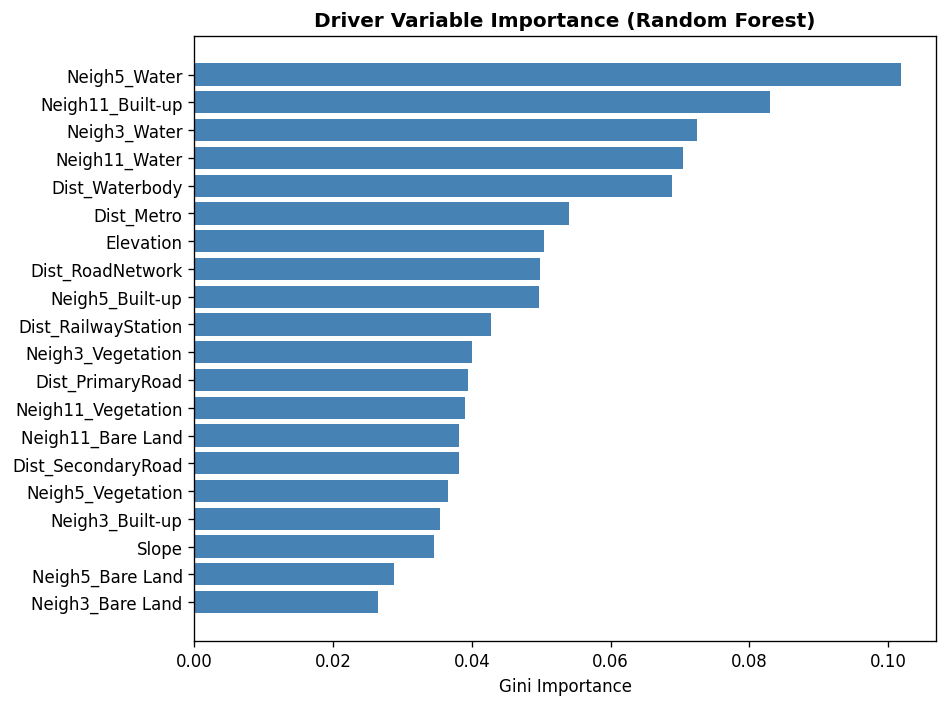

In [25]:
# Use RF's built-in feature importance (fast & reliable)
rf_model = stacked2.named_estimators_['rf']
importances = rf_model.feature_importances_

feat_names_full = (
    list(selected_drivers.keys()) +
    [f'Neigh{s}_{CLASS_MAP[c]}' for s in (3,5,11) for c in CLASS_IDS]
)
feat_names_full = feat_names_full[:len(importances)]

imp_df = pd.DataFrame({'Feature': feat_names_full, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False)
print('Feature importances (RF Gini):')
print(imp_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(imp_df))
ax.barh(y_pos, imp_df['Importance'], color='steelblue', align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(imp_df['Feature'].tolist())
ax.invert_yaxis()
ax.set_xlabel('Gini Importance')
ax.set_title('Driver Variable Importance (Random Forest)', fontweight='bold')
plt.tight_layout()
plt.savefig('driver_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 14. Export GeoTIFFs

In [26]:
def save_geotiff(array, meta, filename, nodata_val=0):
    out_meta = meta.copy()
    out_meta.update({'dtype': 'int16', 'nodata': nodata_val, 'count': 1})
    arr = array.copy().astype(np.int16)
    arr[~valid_mask] = nodata_val
    with rasterio.open(filename, 'w', **out_meta) as dst:
        dst.write(arr, 1)
    print(f'Saved: {filename}')

save_geotiff(L15_sim, meta, 'simulated_2015.tif')
save_geotiff(L35_sim, meta, 'projected_2035.tif')
save_geotiff(L45_sim, meta, 'projected_2045.tif')

# Export per-class transition probability maps
pot_2025 = predict_transition_potential(stacked2, scaler2, selected_drivers, L25, valid_mask)
for i, cid in enumerate(stacked2.classes_):
    if cid not in CLASS_MAP:
        continue
    out_meta = meta.copy()
    out_meta.update({'dtype': 'float32', 'nodata': -9999, 'count': 1})
    fname = f'transition_potential_{CLASS_MAP[cid].replace(" ","_")}.tif'
    prob_map = pot_2025[:, :, i].copy()
    prob_map[~valid_mask] = -9999
    with rasterio.open(fname, 'w', **out_meta) as dst:
        dst.write(prob_map, 1)
    print(f'Saved: {fname}')


Saved: simulated_2015.tif
Saved: projected_2035.tif
Saved: projected_2045.tif
Saved: transition_potential_Built-up.tif
Saved: transition_potential_Vegetation.tif
Saved: transition_potential_Water.tif
Saved: transition_potential_Bare_Land.tif


## 15. Summary Report

In [27]:
print('=' * 70)
print('BANGALORE LULC CA-ANN — IMPROVED MODEL SUMMARY REPORT')
print('=' * 70)
print(f'Study area valid pixels : {valid_mask.sum():,}')
print(f'Pixel resolution        : {abs(meta["transform"].a):.1f} m')
print(f'Total study area        : {valid_mask.sum()*PIXEL_AREA_HA:,.0f} ha')
print(f'\nModel Architecture      : Stacked (RF-200 + MLP-256/128/64/32) → LogReg')
print(f'Selected drivers        : {list(selected_drivers.keys())}')
print(f'Feature count           : {len(feat_names_full)}')
print(f'Training samples/class  : {SAMPLES_PER_CLASS:,} (spatially stratified)')
print(f'CV Kappa (calibration)  : {np.mean(kappas):.4f} ± {np.std(kappas):.4f}')
print(f'\nCALIBRATION VALIDATION (Sim 2015 vs Obs 2015):')
print(f'  Overall Agreement      : {oa:.2f}%')
print(f'  Kappa                  : {kappa:.4f}')
print(f'  Quantity Disagreement  : {total_qd:.2f}%')
print(f'  Allocation Disagreement: {total_ad:.2f}%')
print(f'\nLULC HISTORICAL CHANGE (Annual Dynamic Degree %):')
print(df_change[['DD 05-15 (%/yr)','DD 15-25 (%/yr)','DD 05-25 (%/yr)']].round(2).to_string())
print(f'\nLULC PROJECTED CHANGE (Annual Dynamic Degree %):')
print(df_dd.round(2).to_string())
print()
print('Improvements over baseline:')
print('  - Stacked RF+MLP ensemble replaces single MLP')
print('  - Multi-scale 3×3/5×5/11×11 neighborhood features')
print('  - Spatially stratified training (8×8 grid blocks)')  
print('  - Collinearity-filtered driver selection')
print('  - Adjacency-constrained CA allocation (no teleportation)')
print('  - Per-step Markov demand (not just start-of-run)')
print('  - Persistence bonus for stable land covers')


BANGALORE LULC CA-ANN — IMPROVED MODEL SUMMARY REPORT
Study area valid pixels : 4,690,224
Pixel resolution        : 30.0 m
Total study area        : 422,120 ha

Model Architecture      : Stacked (RF-200 + MLP-256/128/64/32) → LogReg
Selected drivers        : ['Elevation', 'Slope', 'Dist_PrimaryRoad', 'Dist_SecondaryRoad', 'Dist_RoadNetwork', 'Dist_Waterbody', 'Dist_RailwayStation', 'Dist_Metro']
Feature count           : 20
Training samples/class  : 15,000 (spatially stratified)
CV Kappa (calibration)  : 0.7728 ± 0.0051

CALIBRATION VALIDATION (Sim 2015 vs Obs 2015):
  Overall Agreement      : 66.96%
  Kappa                  : 0.4816
  Quantity Disagreement  : 10.95%
  Allocation Disagreement: 55.14%

LULC HISTORICAL CHANGE (Annual Dynamic Degree %):
            DD 05-15 (%/yr)  DD 15-25 (%/yr)  DD 05-25 (%/yr)
Built-up               2.89             7.34             6.18
Vegetation            -0.08            -0.63            -0.35
Water                 12.34             2.73         